In [1]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt 

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\baw61\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


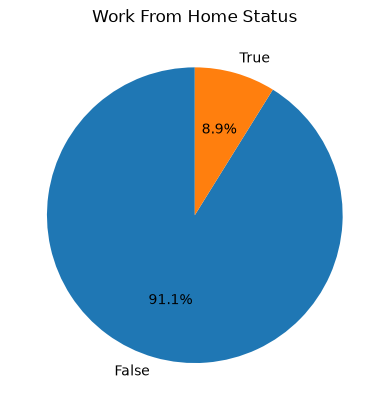

In [8]:
df['job_work_from_home'].value_counts().plot(kind='pie', startangle=90, autopct='%1.1f%%')
plt.title('Work From Home Status')
plt.ylabel('')
plt.show()

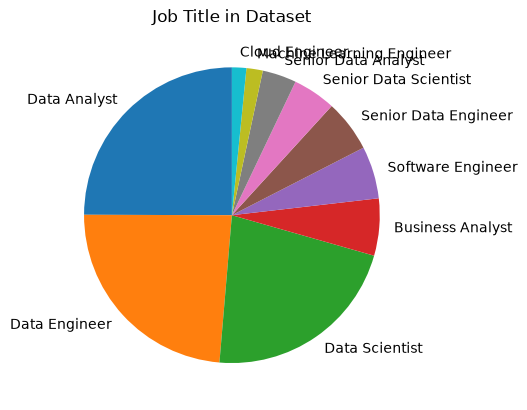

In [4]:
df['job_title_short'].value_counts().plot(kind='pie')
plt.title('Job Title in Dataset')
plt.ylabel('')
plt.show()

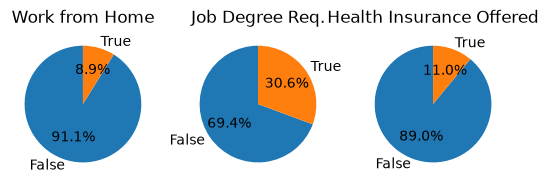

In [20]:
fig, ax = plt.subplots(1, 3)

dict_column = {
    'job_work_from_home': 'Work from Home',
    'job_no_degree_mention': 'Job Degree Req.',
    'job_health_insurance': 'Health Insurance Offered'
}

for i, (column,title) in enumerate(dict_column.items()):
    ax[i].pie(df[column].value_counts(), startangle=90, autopct='%1.1f%%', labels=['False', 'True'])
    ax[i].set_title(title)


plt.show()

In [21]:
df_DA = df[df['job_title_short'] == 'Data Analyst']

Text(0.5, 1.0, 'Proportion of Data Analyst Jobs Mentioning Health Insurance')

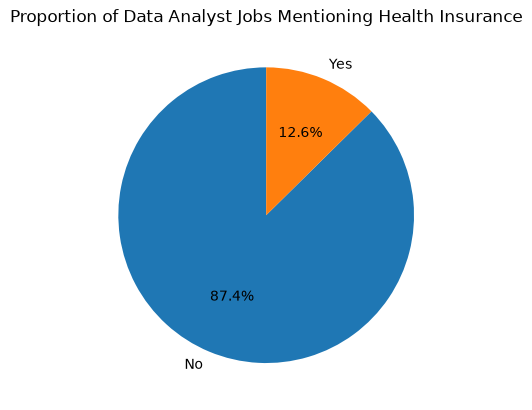

In [28]:
df_DA['job_health_insurance'].value_counts().plot(kind='pie', startangle=90, autopct='%1.1f%%', labels=['No', 'Yes'])
plt.title('Proportion of Data Analyst Jobs Mentioning Health Insurance')

In [42]:
df_ft_pt = df[(df['job_schedule_type'] == 'Full-time') | (df['job_schedule_type'] == 'Part-time')]
counts = df_ft_pt['job_schedule_type'].value_counts()

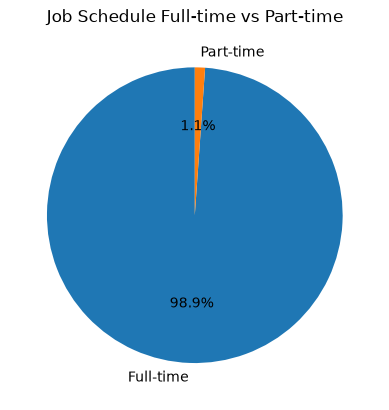

In [47]:
plt.pie(counts, labels=counts.index, startangle=90, autopct='%1.1f%%')
plt.title('Job Schedule Full-time vs Part-time')
plt.show()

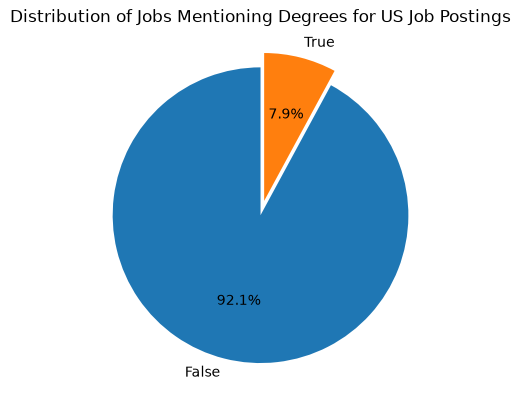

In [56]:
df_US = df[df['job_location'] == 'United States']
data = df_US['job_no_degree_mention'].value_counts()
plt.pie(data, labels=data.index, startangle=90, autopct='%1.1f%%',explode=[0, 0.1])
plt.title('Distribution of Jobs Mentioning Degrees for US Job Postings')
plt.show()